# SemCor Embedding Index Explore

This notebook builds a noun-annotation embedding index from the SemCor dataset.
It samples the first 5000 sentences, computes noun span embeddings with the text encoder,
and supports lookup by individual token, full phrase, or lemma.


In [1]:
from collections import defaultdict
from itertools import islice
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

from prepare_semcor import NO_SPACE_AFTER, NO_SPACE_BEFORE, iter_sentence_records, load_semcor_stats
from text_processing import encode_chunk_batch, get_token_indices_for_phrase, normalize_text


In [2]:
BASE_DIR = Path("data/semcor")
NUM_SENTENCES = 37176
BATCH_SIZE = 8
TEXT_ENCODER_NAME_OR_PATH = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"
OUTPUT_PATH = Path(f"semcor_noun_embedding_index_{NUM_SENTENCES}.pkl")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stats = load_semcor_stats(BASE_DIR)
pd.Series(stats)


dataset_name                                                             SemCor
base_dir                                   /home/xiaoyue/LiteSemRAG/data/semcor
nltk_data_dir                 /home/xiaoyue/LiteSemRAG/data/semcor/raw/nltk_...
processed_dir                    /home/xiaoyue/LiteSemRAG/data/semcor/processed
resources                                            [semcor, wordnet, omw-1.4]
file_count                                                                  352
sentence_count                                                            37176
token_count                                                              820410
annotation_count                                                         778587
semantic_annotation_count                                                235079
noun_annotation_count                                                     88892
oov_entity_count                                                           9684
multiword_annotation_count              

In [3]:
tokenizer = None
text_encoder = None


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise TypeError("A fast tokenizer is required because SemCor indexing uses offset_mapping.")

    loaded_text_encoder = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_text_encoder.to(device)
    loaded_text_encoder.eval()
    return loaded_tokenizer, loaded_text_encoder


def ensure_text_encoder_loaded():
    global tokenizer, text_encoder
    if tokenizer is None or text_encoder is None:
        tokenizer, text_encoder = load_text_encoder(TEXT_ENCODER_NAME_OR_PATH, DEVICE)
        print(f"Loaded text encoder on {DEVICE}")
    return tokenizer, text_encoder


def load_semcor_sentence_sample(base_dir: Path, num_sentences: int):
    return list(islice(iter_sentence_records(base_dir), num_sentences))


def build_token_char_spans(sentence_text: str, tokens: list[str]):
    spans = []
    cursor = 0

    for token in tokens:
        while cursor < len(sentence_text) and sentence_text[cursor].isspace():
            cursor += 1

        start_char = sentence_text.find(token, cursor)
        if start_char < 0:
            raise ValueError(
                f"Could not align token {token!r} inside sentence starting from char {cursor}.\n"
                f"text={sentence_text!r}"
            )

        gap_text = sentence_text[cursor:start_char]
        if any(not ch.isspace() for ch in gap_text):
            raise ValueError(
                f"Unexpected non-whitespace gap before token {token!r}.\n"
                f"gap={gap_text!r}\ntext={sentence_text!r}"
            )

        end_char = start_char + len(token)
        spans.append((start_char, end_char))
        cursor = end_char

    return spans


def collect_sentence_noun_annotations(sentence_record: dict):
    token_char_spans = build_token_char_spans(sentence_record["text"], sentence_record["tokens"])
    noun_records = []

    for annotation in sentence_record.get("noun_annotations", []):
        token_start = int(annotation["token_start"])
        token_end = int(annotation["token_end"])
        if token_end <= token_start:
            continue

        start_char = token_char_spans[token_start][0]
        end_char = token_char_spans[token_end - 1][1]
        surface_text = sentence_record["text"][start_char:end_char]
        normalized_surface = normalize_text(surface_text)
        normalized_tokens = [normalize_text(token) for token in annotation["tokens"]]

        noun_records.append(
            {
                "surface_text": surface_text,
                "normalized_surface": normalized_surface,
                "normalized_tokens": normalized_tokens,
                "char_span": (int(start_char), int(end_char)),
                "token_span": (token_start, token_end),
                **annotation,
            }
        )

    return noun_records


def build_semcor_noun_embedding_index(
    sentences,
    text_encoder,
    tokenizer,
    device,
    batch_size=8,
):
    store = {
        "sentences": sentences,
        "index": defaultdict(list),
        "surface_index": defaultdict(list),
        "lemma_index": defaultdict(list),
        "config": {
            "batch_size": batch_size,
            "device": device,
            "text_encoder_name_or_path": TEXT_ENCODER_NAME_OR_PATH,
            "num_sentences": len(sentences),
        },
    }

    indexed_sentence_count = 0
    record_count = 0

    for batch_start in range(0, len(sentences), batch_size):
        batch_end = min(batch_start + batch_size, len(sentences))
        batch_sentences = sentences[batch_start:batch_end]
        batch_texts = [sentence["text"] for sentence in batch_sentences]
        token_embeddings_batch, offsets_batch = encode_chunk_batch(
            batch_texts,
            text_encoder,
            tokenizer,
            device,
        )

        for local_idx, (sentence_record, token_embeddings, offsets) in enumerate(
            zip(batch_sentences, token_embeddings_batch, offsets_batch)
        ):
            sentence_index = batch_start + local_idx
            noun_records = collect_sentence_noun_annotations(sentence_record)
            kept_for_sentence = 0

            for noun_record in noun_records:
                start_char, end_char = noun_record["char_span"]
                token_indices = get_token_indices_for_phrase(start_char, end_char, offsets)
                if not token_indices:
                    continue

                embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
                record = {
                    "sentence_index": int(sentence_index),
                    "sentence_id": sentence_record["sentence_id"],
                    "sentence_text": sentence_record["text"],
                    "annotation_index": int(noun_record["annotation_index"]),
                    "surface_text": noun_record["surface_text"],
                    "normalized_surface": noun_record["normalized_surface"],
                    "tokens": list(noun_record["tokens"]),
                    "normalized_tokens": list(noun_record["normalized_tokens"]),
                    "token_span": tuple(noun_record["token_span"]),
                    "char_span": tuple(noun_record["char_span"]),
                    "lemma": noun_record["lemma"],
                    "pos": noun_record["pos"],
                    "sense_key": noun_record["sense_key"],
                    "synset_name": noun_record["synset_name"],
                    "synset_definition": noun_record["synset_definition"],
                    "lexname": noun_record["lexname"],
                    "embedding": embedding,
                }

                store["surface_index"][record["normalized_surface"]].append(record)
                if record["lemma"]:
                    store["lemma_index"][normalize_text(record["lemma"])].append(record)

                seen_query_tokens = set()
                for token in record["normalized_tokens"]:
                    if token and token not in seen_query_tokens:
                        store["index"][token].append(record)
                        seen_query_tokens.add(token)

                kept_for_sentence += 1
                record_count += 1

            if kept_for_sentence > 0:
                indexed_sentence_count += 1

        print(f"Processed {batch_end}/{len(sentences)} sentences")

    store["stats"] = {
        "num_sampled_sentences": len(sentences),
        "num_indexed_sentences": indexed_sentence_count,
        "num_records": record_count,
        "num_unique_query_tokens": len(store["index"]),
        "num_unique_surface_terms": len(store["surface_index"]),
        "num_unique_lemmas": len(store["lemma_index"]),
    }
    return store


def lookup_semcor_embeddings(store, query_text, mode="token"):
    normalized_query = normalize_text(query_text.strip())
    if mode == "token":
        records = store["index"].get(normalized_query, [])
    elif mode == "surface":
        records = store["surface_index"].get(normalized_query, [])
    elif mode == "lemma":
        records = store["lemma_index"].get(normalized_query, [])
    else:
        raise ValueError("mode must be one of: token, surface, lemma")

    enriched_records = []
    for record in records:
        item = dict(record)
        item["lookup_query"] = normalized_query
        item["lookup_mode"] = mode
        enriched_records.append(item)
    return enriched_records


def lookup_semcor_dataframe(store, query_text, mode="token", limit=20):
    records = lookup_semcor_embeddings(store, query_text, mode=mode)
    rows = []
    for record in records[:limit]:
        rows.append(
            {
                "sentence_index": record["sentence_index"],
                "sentence_id": record["sentence_id"],
                "surface_text": record["surface_text"],
                "tokens": record["tokens"],
                "lemma": record["lemma"],
                "synset_name": record["synset_name"],
                "synset_definition": record["synset_definition"],
                "sentence_text": record["sentence_text"],
                "embedding_shape": tuple(record["embedding"].shape),
            }
        )
    return pd.DataFrame(rows)


def token_frequency_dataframe(store, limit=None):
    rows = [
        {
            "token": token,
            "num_records": len(records),
            "num_unique_synsets": len(
                {record.get("synset_name") or "(unknown synset)" for record in records}
            ),
        }
        for token, records in store["index"].items()
    ]
    df = pd.DataFrame(rows).sort_values(
        by=["num_records", "token"],
        ascending=[False, True],
        ignore_index=True,
    )
    if limit is not None:
        return df.head(limit)
    return df


def _scatter_semcor_by_synset(coords, records, synset_to_color, title, xlabel, ylabel, annotate=False):
    plt.figure(figsize=(9, 7))

    for synset_name in sorted(synset_to_color):
        indices = [idx for idx, record in enumerate(records) if (record.get("synset_name") or "(unknown synset)") == synset_name]
        if not indices:
            continue
        plt.scatter(
            coords[indices, 0],
            coords[indices, 1],
            s=48,
            alpha=0.8,
            color=synset_to_color[synset_name],
            label=synset_name,
        )

    if annotate:
        for idx, record in enumerate(records):
            plt.annotate(
                f"{record['surface_text']} [{record['sentence_index']}]",
                (coords[idx, 0], coords[idx, 1]),
                fontsize=8,
                alpha=0.75,
            )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title="synset_name", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def _print_synset_descriptions(records):
    synset_descriptions = {}
    for record in records:
        synset_name = record.get("synset_name") or "(unknown synset)"
        synset_definition = record.get("synset_definition") or "(no definition available)"
        synset_descriptions.setdefault(synset_name, synset_definition)

    print("Synset descriptions:")
    for synset_name in sorted(synset_descriptions):
        print(f"- {synset_name}: {synset_descriptions[synset_name]}")


def plot_semcor_term_embeddings(store, query_text, mode="token", perplexity=30, random_state=42, annotate=False):
    records = lookup_semcor_embeddings(store, query_text, mode=mode)
    if not records:
        print(f"No records found for {query_text!r} with mode={mode!r}")
        return None

    if len(records) < 2:
        print(f"Only {len(records)} record found for {query_text!r}; at least 2 are required for visualization.")
        return {"records": records}

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    synset_names = sorted({record.get("synset_name") or "(unknown synset)" for record in records})
    cmap = plt.cm.get_cmap("tab20", max(1, len(synset_names)))
    synset_to_color = {synset_name: cmap(idx) for idx, synset_name in enumerate(synset_names)}
    normalized_query = normalize_text(query_text.strip())

    pca_coords = PCA(n_components=2).fit_transform(embeddings)
    _scatter_semcor_by_synset(
        pca_coords,
        records,
        synset_to_color,
        title=f"PCA projection for '{normalized_query}' ({len(records)} records)",
        xlabel="PC1",
        ylabel="PC2",
        annotate=annotate,
    )

    tsne_perplexity = min(perplexity, len(records) - 1)
    tsne_coords = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(embeddings)
    _scatter_semcor_by_synset(
        tsne_coords,
        records,
        synset_to_color,
        title=f"t-SNE projection for '{normalized_query}' ({len(records)} records, perplexity={tsne_perplexity})",
        xlabel="t-SNE-1",
        ylabel="t-SNE-2",
        annotate=annotate,
    )

    _print_synset_descriptions(records)

    return {
        "records": records,
        "embeddings": embeddings,
        "synset_to_color": synset_to_color,
        "pca_coords": pca_coords,
        "tsne_coords": tsne_coords,
    }


In [4]:
sampled_sentences = load_semcor_sentence_sample(BASE_DIR, NUM_SENTENCES)
print(f"Loaded {len(sampled_sentences)} SemCor sentences")
print(sampled_sentences[0]["sentence_id"])
print(sampled_sentences[0]["text"])
pd.DataFrame(collect_sentence_noun_annotations(sampled_sentences[0]))[
    [
        "annotation_index",
        "surface_text",
        "tokens",
        "char_span",
        "lemma",
        "synset_name",
        "synset_definition",
    ]
]


Loaded 37176 SemCor sentences
brown1/tagfiles/br-a01.xml:1
The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced ``no evidence'' that any irregularities took place.


,annotation_index,surface_text,tokens,char_span,lemma,synset_name,synset_definition
0,1,Fulton County Grand Jury,"[Fulton, County, Grand, Jury]","(4, 28)",group,group.n.01,any number of entities (members) considered as...
1,3,Friday,[Friday],"(34, 40)",friday,friday.n.01,the sixth day of the week; the fifth working day
2,5,investigation,[investigation],"(44, 57)",investigation,probe.n.01,an inquiry into unfamiliar or questionable act...
3,7,Atlanta,[Atlanta],"(61, 68)",atlanta,atlanta.n.01,state capital and largest city of Georgia; chi...
4,10,primary election,"[primary, election]","(78, 94)",primary_election,primary.n.01,a preliminary election where delegates or nomi...
5,14,evidence,[evidence],"(109, 117)",evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...
6,18,irregularities,[irregularities],"(129, 143)",irregularity,abnormality.n.04,behavior that breaches the rule or etiquette o...


In [5]:
if OUTPUT_PATH.exists():
    with OUTPUT_PATH.open("rb") as handle:
        embedding_store = pickle.load(handle)
    print(f"Loaded cached index from {OUTPUT_PATH}")
else:
    ensure_text_encoder_loaded()
    embedding_store = build_semcor_noun_embedding_index(
        sentences=sampled_sentences,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        device=DEVICE,
        batch_size=BATCH_SIZE,
    )
    with OUTPUT_PATH.open("wb") as handle:
        pickle.dump(embedding_store, handle)
    print(f"Saved new index to {OUTPUT_PATH}")

embedding_store["stats"]


Loaded cached index from semcor_noun_embedding_index_37176.pkl


{'num_sampled_sentences': 37176,
 'num_indexed_sentences': 18574,
 'num_records': 88886,
 'num_unique_query_tokens': 15861,
 'num_unique_surface_terms': 18669,
 'num_unique_lemmas': 11536}

In [6]:
token_frequency_dataframe(embedding_store, limit=50)


,token,num_records,num_unique_synsets
0,man,517,25
1,time,495,28
2,of,446,133
3,years,309,8
4,way,283,14
5,men,270,17
6,people,270,7
7,life,265,30
8,day,238,18
9,world,234,21


In [7]:
lookup_semcor_dataframe(embedding_store, "election", mode="token", limit=10)


,sentence_index,sentence_id,surface_text,tokens,lemma,synset_name,synset_definition,sentence_text,embedding_shape
0,0,brown1/tagfiles/br-a01.xml:1,primary election,"[primary, election]",primary_election,primary.n.01,a preliminary election where delegates or nomi...,The Fulton County Grand Jury said Friday an in...,"(1024,)"
1,1,brown1/tagfiles/br-a01.xml:2,election,[election],election,election.n.01,a vote to select the winner of a position or p...,The jury further said in term end presentments...,"(1024,)"
2,1,brown1/tagfiles/br-a01.xml:2,election,[election],election,election.n.01,a vote to select the winner of a position or p...,The jury further said in term end presentments...,"(1024,)"
3,3,brown1/tagfiles/br-a01.xml:4,election,[election],election,election.n.01,a vote to select the winner of a position or p...,``Only a relative handful of such reports was ...,"(1024,)"
4,4,brown1/tagfiles/br-a01.xml:5,election,[election],election,election.n.01,a vote to select the winner of a position or p...,The jury said it did find that many of Georgia...,"(1024,)"
5,37,brown1/tagfiles/br-a01.xml:38,election,[election],election,election.n.01,a vote to select the winner of a position or p...,His political career goes back to his election...,"(1024,)"
6,47,brown1/tagfiles/br-a01.xml:48,general election,"[general, election]",general_election,general_election.n.01,a national or state election; candidates are c...,Five per cent of the voters in each county mus...,"(1024,)"
7,74,brown1/tagfiles/br-a01.xml:75,election,[election],election,election.n.01,a vote to select the winner of a position or p...,"After a long, hot controversy, Miller County h...","(1024,)"
8,76,brown1/tagfiles/br-a01.xml:77,election,[election],election,election.n.01,a vote to select the winner of a position or p...,Davis received 1119 votes in Saturday's electi...,"(1024,)"
9,78,brown1/tagfiles/br-a01.xml:79,election,[election],election,election.n.01,a vote to select the winner of a position or p...,"``This was the coolest, calmest election I eve...","(1024,)"


In [8]:
lookup_semcor_dataframe(embedding_store, "primary election", mode="surface", limit=10)


,sentence_index,sentence_id,surface_text,tokens,lemma,synset_name,synset_definition,sentence_text,embedding_shape
0,0,brown1/tagfiles/br-a01.xml:1,primary election,"[primary, election]",primary_election,primary.n.01,a preliminary election where delegates or nomi...,The Fulton County Grand Jury said Friday an in...,"(1024,)"


In [9]:
lookup_semcor_dataframe(embedding_store, "evidence", mode="lemma", limit=10)


,sentence_index,sentence_id,surface_text,tokens,lemma,synset_name,synset_definition,sentence_text,embedding_shape
0,0,brown1/tagfiles/br-a01.xml:1,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,The Fulton County Grand Jury said Friday an in...,"(1024,)"
1,852,brown1/tagfiles/br-b20.xml:39,evidence,[evidence],evidence,evidence.n.02,an indication that makes something evident,Another piece of evidence appears in a dispatc...,"(1024,)"
2,1310,brown1/tagfiles/br-d02.xml:9,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,If Bultmann's own definition of myth is strict...,"(1024,)"
3,1311,brown1/tagfiles/br-d02.xml:10,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,Nor is it necessary to look for such evidence ...,"(1024,)"
4,1424,brown1/tagfiles/br-d03.xml:62,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,Further evidence that Roman Catholicism enjoys...,"(1024,)"
5,2140,brown1/tagfiles/br-f03.xml:22,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,Skeptics may deny the more startling phenomena...,"(1024,)"
6,2172,brown1/tagfiles/br-f03.xml:54,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,Some time later the missing part of the relic ...,"(1024,)"
7,2223,brown1/tagfiles/br-f10.xml:32,evidence,[evidence],evidence,evidence.n.03,(law) all the means by which any alleged matte...,And she felt amply rewarded for her suffering ...,"(1024,)"
8,2286,brown1/tagfiles/br-f10.xml:95,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,The evidence shows that fake therapeutic machi...,"(1024,)"
9,2376,brown1/tagfiles/br-f19.xml:84,evidence,[evidence],evidence,evidence.n.01,your basis for belief or disbelief; knowledge ...,"In fact, there is much evidence to indicate th...","(1024,)"


/tmp/ipykernel_834525/1461684786.py:311: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, len(synset_names)))


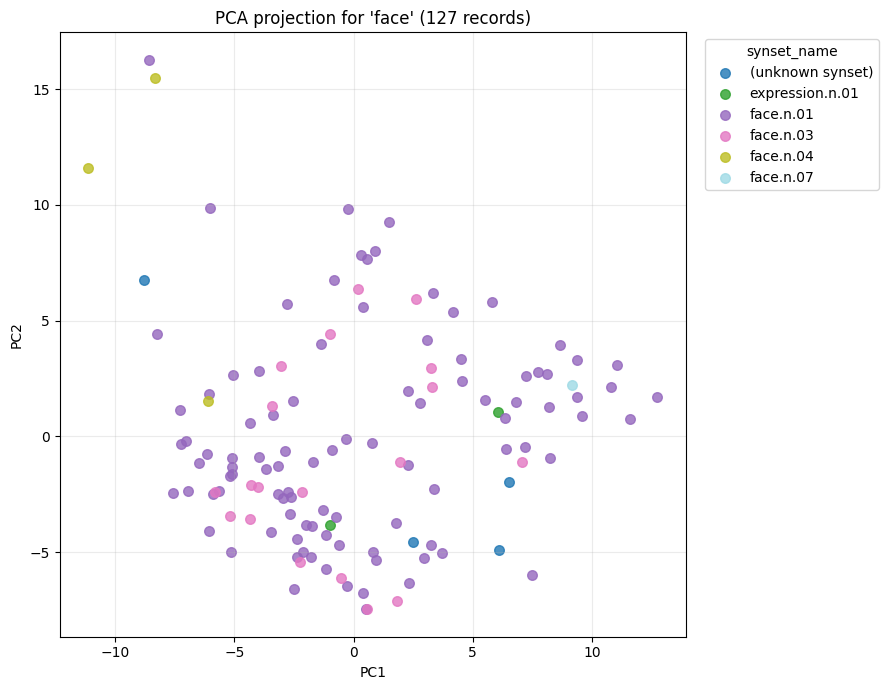

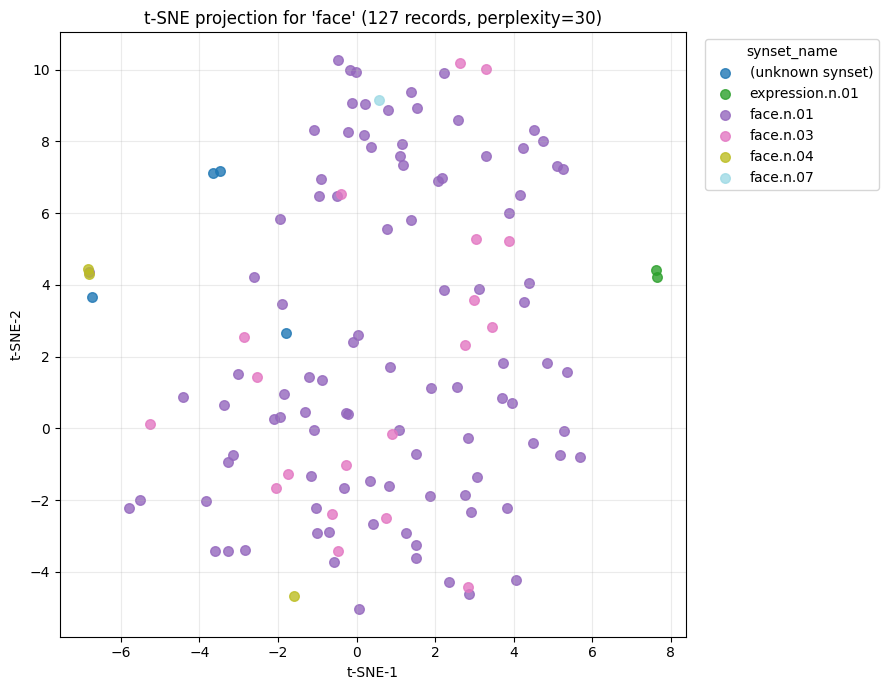

Synset descriptions:
- (unknown synset): (no definition available)
- expression.n.01: the feelings expressed on a person's face
- face.n.01: the front of the human head from the forehead to the chin and ear to ear
- face.n.03: the general outward appearance of something
- face.n.04: the striking or working surface of an implement
- face.n.07: the part of an animal corresponding to the human face


{'records': [{'sentence_index': 1262,
   'sentence_id': 'brown1/tagfiles/br-d01.xml:44',
   'sentence_text': "I hear the boot of Lucifer, I see his filthy face''!",
   'annotation_index': 11,
   'surface_text': 'face',
   'normalized_surface': 'face',
   'tokens': ['face'],
   'normalized_tokens': ['face'],
   'token_span': (11, 12),
   'char_span': (45, 49),
   'lemma': 'face',
   'pos': 'NN',
   'sense_key': 'face%1:07:00::',
   'synset_name': 'face.n.03',
   'synset_definition': 'the general outward appearance of something',
   'lexname': 'noun.attribute',
   'embedding': array([ 0.15608361,  0.38642666, -0.35139167, ...,  0.33344522,
          -0.84838635,  0.15470764], dtype=float32),
   'lookup_query': 'face',
   'lookup_mode': 'surface'},
  {'sentence_index': 2694,
   'sentence_id': 'brown1/tagfiles/br-g15.xml:55',
   'sentence_text': "Piepsam calls the cyclist ``cur'' and ``puppy'' among other things, and at the crisis of his fit a little fox-terrier stands before him and howls

In [12]:
plot_semcor_term_embeddings(embedding_store, "face", mode="surface", annotate=False)
